# NB20: P2 Futile-Cycling Adipocytes — Does Exercise Promote UCP1-Independent Thermogenesis in Visceral Fat?

## Why this notebook exists

The main finding from NB15 is that Fndc5 — the gene that encodes irisin, a hormone released during exercise — is upregulated in visceral fat stem cells (called Areg cells) specifically during exercise. The question this notebook asks is: **so what?** If irisin is being produced locally in visceral fat stem cells, what downstream effect might it have on the fat tissue itself?

The classical answer to "how does fat burn energy" is UCP1 — a protein found in brown fat and beige fat that generates heat by wasting energy. But visceral fat (the fat around your organs — the dangerous kind linked to diabetes and heart disease) barely browns. UCP1-based thermogenesis barely happens there. So if irisin is doing something in visceral fat, it has to be through a different mechanism.

That mechanism is **futile cycling**, specifically in a fat cell subtype called **P2 adipocytes**.

## What is futile cycling?

Normally, cells are efficient — they don't waste energy on purpose. Futile cycling is the opposite: a cell simultaneously runs a process that builds something AND the reverse process that breaks it down, consuming ATP (cellular energy currency) and producing heat without accomplishing anything useful from an engineering standpoint. It's like driving with one foot on the gas and one on the brake.

P2 adipocytes (a subpopulation of fat cells first described by Sun et al. 2020 in *Nature*) do this by running high levels of oxidative phosphorylation (OXPHOS — the mitochondrial energy production machinery) without UCP1. They burn energy through futile ion transport and substrate cycling. They are:
- UCP1-low (not classic brown/beige fat)
- OXPHOS-high (lots of mitochondrial activity)
- Found in visceral depots where classic browning barely occurs
- Conserved in humans

If exercise-induced irisin from Areg cells promotes P2 expansion or activation in visceral fat, that would be a mechanistically complete story: **exercise → Fndc5/irisin in stem cells → P2 futile-cycling adipocytes activated → more energy burned in visceral fat without UCP1**.

## Important caveat upfront

The Yang et al. atlas used SVF enrichment — a technique that deliberately removes mature fat cells in order to capture rare stem cells. P2 adipocytes are mature fat cells. This means the dataset we're working with is biased *against* finding them. If we find a P2 signal despite this, it's real. If we don't, it may just be a sampling artifact, not biological absence. We'll report this honestly.

## Paper context

Yang et al. 2022 (*Cell Metabolism*) studied how exercise counteracts obesity at the level of individual cell types across visceral fat (vWAT), subcutaneous fat (scWAT), and skeletal muscle. Their key finding was that mesenchymal stem cells (MSCs — fat and muscle stem cells) are the central responders to both obesity and exercise. This notebook extends their data to ask whether exercise also remodels the mature fat cell compartment toward a more thermogenic P2 state.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sc.settings.verbosity = 1
sc.settings.figdir = 'figures/'

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


## Section 1: Load data and focus on visceral fat

We load the full Yang et al. atlas and restrict to visceral fat (vWAT). The four experimental conditions are:
- **SC** — standard chow diet, sedentary (healthy baseline)
- **TC** — standard chow diet, trained/exercised (exercise effect in healthy mice)
- **SH** — high-fat diet, sedentary (obesity effect)
- **TH** — high-fat diet, trained/exercised (exercise as a therapy for obesity — the most clinically relevant comparison)

In [2]:
adata = sc.read_h5ad('../GSE183288_Single_cell_atlas.h5ad')
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

vwat = adata[adata.obs['tissue'] == 'vWAT'].copy()

print(f'Full atlas: {adata.shape[0]:,} cells')
print(f'vWAT subset: {vwat.shape[0]:,} cells')
print(f'\nConditions:')
print(vwat.obs['intervention_group'].value_counts())
print(f'\nvWAT cell states:')
print(vwat.obs['cell_state_label'].value_counts().head(10))

Full atlas: 204,883 cells
vWAT subset: 78,860 cells

Conditions:
intervention_group
TH    27598
TC    20869
SC    18668
SH    11725
Name: count, dtype: int64

vWAT cell states:
cell_state_label
CP            26001
WAT_IPC       15824
Areg           6197
NK             5498
pre_CP         4687
CD4_Memory     2559
Fibroblast     2358
cDC2           1808
nILC2          1703
Treg           1257
Name: count, dtype: int64


## Section 2: Define the P2 gene signature

**The problem:** How do you identify P2 fat cells without a single definitive marker gene?

P2 cells are defined by high oxidative phosphorylation (OXPHOS) activity combined with low UCP1. OXPHOS is the process by which mitochondria produce ATP — it involves a series of protein complexes (called Complex I through V) that chain together to transfer electrons and pump protons. P2 cells have abnormally high expression of these complex subunit genes.

The marker gene set comes from Sun et al. 2020 (*Nature*) and subsequent work:
- **Atp5k** — subunit of Complex V (ATP synthase)
- **Uqcrb** — subunit of Complex III
- **Ndufb5** — subunit of Complex I
- **Cox7a1** — subunit of Complex IV
- **Ucp1** — the negative marker (P2 cells are UCP1-low; note: absent from this dataset, which is itself informative)

We score each cell for the P2 signature using `scanpy.score_genes()` — this computes how much more a cell expresses the P2 genes compared to a random set of background genes of similar expression level. A score near zero = average. Positive = P2-like.

In [3]:
p2_markers = ['Atp5k', 'Uqcrb', 'Ndufb5', 'Cox7a1', 'Ppargc1a']
p2_present = [g for g in p2_markers if g in vwat.var_names]
p2_absent  = [g for g in p2_markers if g not in vwat.var_names]

print('P2 markers present:', p2_present)
print('P2 markers absent (UCP1 expected absent due to SVF enrichment):', p2_absent)
print()

# Expression summary per marker
print(f'{"Gene":<12} {"Mean":>8} {"% Expressing":>14}')
print('-' * 38)
for g in p2_present:
    vals = vwat[:, g].X.toarray().flatten()
    print(f'{g:<12} {vals.mean():>8.4f} {(vals>0).mean()*100:>13.1f}%')

# Score cells
sc.tl.score_genes(vwat, gene_list=p2_present, score_name='p2_score')
print(f'\nP2 score computed. Range: {vwat.obs["p2_score"].min():.3f} to {vwat.obs["p2_score"].max():.3f}')

P2 markers present: ['Atp5k', 'Uqcrb', 'Ndufb5', 'Cox7a1', 'Ppargc1a']
P2 markers absent (UCP1 expected absent due to SVF enrichment): []

Gene             Mean   % Expressing
--------------------------------------


Atp5k          0.6378          40.7%
Uqcrb          0.8964          53.1%


Ndufb5         0.7134          45.1%
Cox7a1         0.0102           0.9%
Ppargc1a       0.0186           1.3%



P2 score computed. Range: -0.758 to 1.888


## Section 3: Which cell types have the highest P2 scores?

**The problem this answers:** Before asking whether exercise changes P2 scores, we need to check that the P2 signal is landing in the right cells — adipocyte-like cells (CP = committed preadipocytes, WAT_IPC = intermediate progenitors), not immune cells or stem cells. If the score is highest in immune cells, the markers are not specific enough to be useful.

P2 score by cell type (top 15):
                           mean    median  count
cell_state_label                                
Epididymis             0.637009  0.762398     54
Epi                    0.540314  0.607997    163
cDC1                   0.224909  0.245870    367
SMC_precursor          0.209337  0.153629     18
vSMC                   0.159731  0.209329     57
Large_artery           0.131376  0.103620     28
cDC2                   0.127510  0.146398   1808
M1                     0.124139  0.135369    604
mo-DC                  0.118730  0.148787    168
Capillary              0.095432  0.090411   1188
Pericyte               0.082165  0.030450    211
Monocyte_Inflammatory  0.064131  0.077584    222
Fibroblast             0.054067  0.066755   2358
Lymphatic              0.031917 -0.017630    130
Large_vessel           0.010665 -0.005231     71


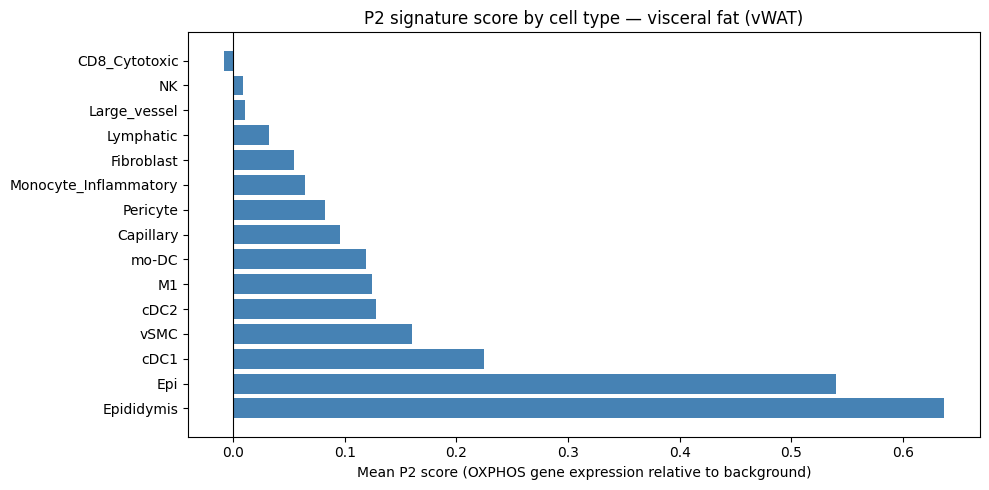

In [4]:
score_by_type = vwat.obs.groupby('cell_state_label')['p2_score'].agg(['mean', 'median', 'count'])
score_by_type = score_by_type.sort_values('mean', ascending=False)

print('P2 score by cell type (top 15):')
print(score_by_type.head(15).to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
top_types = score_by_type[score_by_type['count'] > 50].head(15)
ax.barh(top_types.index, top_types['mean'], color='steelblue')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean P2 score (OXPHOS gene expression relative to background)')
ax.set_title('P2 signature score by cell type — visceral fat (vWAT)')
plt.tight_layout()
plt.show()

## Section 4: P2 score across the four experimental conditions

**The question:** Does exercise increase P2 scores in adipocyte-like cells? And does obesity suppress them?

We focus on the adipocyte-lineage cell types: CP (committed preadipocytes — fat cells that have committed to becoming mature fat cells but haven't fully matured yet) and WAT_IPC (intermediate progenitor cells — one step earlier in the differentiation process). These are the most abundant adipocyte-lineage cells in the SVF-enriched dataset.

The four conditions tell us four things:
- **SC→TC** (healthy sedentary → healthy trained): pure exercise effect
- **SC→SH** (healthy sedentary → obese sedentary): pure obesity effect  
- **SH→TH** (obese sedentary → obese trained): therapeutic exercise — most clinically relevant

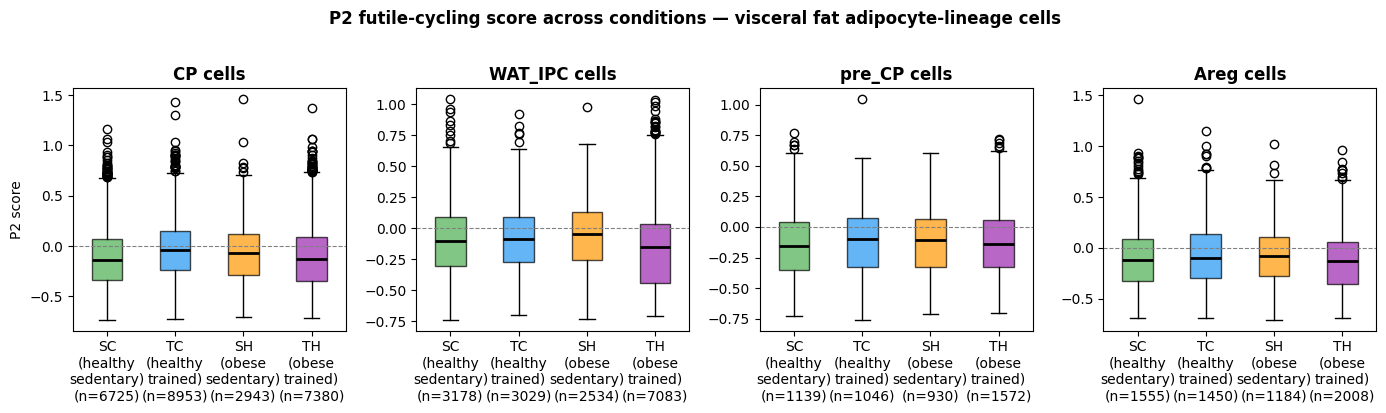

Mean P2 score by cell type and condition:
Cell type          SC        TC        SH        TH
--------------------------------------------------
CP             -0.124    -0.044    -0.078    -0.117
WAT_IPC        -0.104    -0.085    -0.065    -0.158
pre_CP         -0.150    -0.116    -0.127    -0.135
Areg           -0.109    -0.069    -0.081    -0.130


In [5]:
adipocyte_types = ['CP', 'WAT_IPC', 'pre_CP', 'Areg']
conditions = ['SC', 'TC', 'SH', 'TH']
condition_labels = {
    'SC': 'SC\n(healthy\nsedentary)',
    'TC': 'TC\n(healthy\ntrained)',
    'SH': 'SH\n(obese\nsedentary)',
    'TH': 'TH\n(obese\ntrained)'
}

fig, axes = plt.subplots(1, len(adipocyte_types), figsize=(14, 4))

for ax, ct in zip(axes, adipocyte_types):
    sub = vwat[vwat.obs['cell_state_label'] == ct]
    data = [sub[sub.obs['intervention_group'] == c].obs['p2_score'].values for c in conditions]
    labels = [f"{condition_labels[c]}\n(n={len(d)})" for c, d in zip(conditions, data)]
    
    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(f'{ct} cells', fontweight='bold')
    ax.set_ylabel('P2 score' if ct == adipocyte_types[0] else '')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('P2 futile-cycling score across conditions — visceral fat adipocyte-lineage cells',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary statistics
print('Mean P2 score by cell type and condition:')
print(f'{"Cell type":<12}', '  '.join(f'{c:>8}' for c in conditions))
print('-' * 50)
for ct in adipocyte_types:
    sub = vwat[vwat.obs['cell_state_label'] == ct]
    row = []
    for c in conditions:
        vals = sub[sub.obs['intervention_group'] == c].obs['p2_score'].values
        row.append(f'{vals.mean():>8.3f}')
    print(f'{ct:<12}', '  '.join(row))

## Section 5: Per-sample correlation — does Areg Fndc5 track with CP P2 score?

**The problem this answers:** Even if both Fndc5 (in Areg stem cells) and P2 score (in CP fat cells) change with exercise, that doesn't mean they're connected. They could both be responding to exercise independently through completely different pathways.

To test whether they might be connected, we use a per-sample correlation. The logic: if irisin produced by Areg cells is promoting P2 activity in neighboring CP cells, then samples where Areg cells express more Fndc5 should also have higher P2 scores in their CP cells. We have ~11 samples across the four conditions — enough for a rough correlation.

**Important caveat:** This is not proof of causation. A positive correlation would be consistent with the irisin→P2 hypothesis but doesn't prove it. Two things can correlate because one causes the other, or because both are caused by a third thing (exercise itself, in this case).

sample condition  areg_fndc5_pct  cp_p2_score  areg_n  cp_n
  SC_1        SC        3.679369    -0.086966     761  2326
  SC_2        SC        6.772908    -0.136153     502  1514
  TC_1        TC        7.451923    -0.028373     416  3110
  TH_3        TH        2.443609    -0.130315    1064  4555
  SH_1        SH        3.947368    -0.059936     532  1550
  TH_1        TH        2.557545    -0.114914     391  1476
  TC_2        TC        9.683794    -0.049783     506  2438
  TH_4        TH        4.882459    -0.074944     553  1349
  TC_3        TC       13.186813    -0.059151     273  1548
  TC_4        TC       12.941176    -0.047618     255  1857
  SH_3        SH        3.035413    -0.103441     593  1309
  SC_3        SC        3.082192    -0.146511     292  2885
  SH_2        SH        8.474576    -0.016920      59    84

Pearson r = 0.628, p = 0.0214 (n=13 samples)


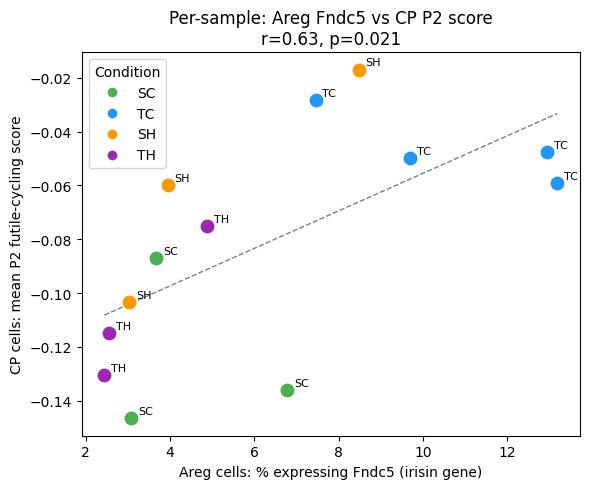

In [6]:
sample_stats = []

for sample in vwat.obs['sample_name'].unique():
    samp = vwat[vwat.obs['sample_name'] == sample]
    cond = samp.obs['intervention_group'].iloc[0]
    
    areg = samp[samp.obs['cell_state_label'] == 'Areg']
    cp   = samp[samp.obs['cell_state_label'] == 'CP']
    
    if areg.n_obs < 10 or cp.n_obs < 10:
        continue
    
    if 'Fndc5' not in vwat.var_names:
        break
    
    fndc5_mean = areg[:, 'Fndc5'].X.toarray().flatten().mean()
    fndc5_pct  = (areg[:, 'Fndc5'].X.toarray().flatten() > 0).mean() * 100
    p2_mean    = cp.obs['p2_score'].mean()
    
    sample_stats.append({
        'sample': sample, 'condition': cond,
        'areg_fndc5_mean': fndc5_mean,
        'areg_fndc5_pct': fndc5_pct,
        'cp_p2_score': p2_mean,
        'areg_n': areg.n_obs, 'cp_n': cp.n_obs
    })

df = pd.DataFrame(sample_stats)
print(df[['sample','condition','areg_fndc5_pct','cp_p2_score','areg_n','cp_n']].to_string(index=False))

if len(df) >= 5:
    r, p = stats.pearsonr(df['areg_fndc5_pct'], df['cp_p2_score'])
    print(f'\nPearson r = {r:.3f}, p = {p:.4f} (n={len(df)} samples)')
    
    fig, ax = plt.subplots(figsize=(6, 5))
    colors = {'SC': '#4CAF50', 'TC': '#2196F3', 'SH': '#FF9800', 'TH': '#9C27B0'}
    for _, row in df.iterrows():
        ax.scatter(row['areg_fndc5_pct'], row['cp_p2_score'],
                   color=colors.get(row['condition'], 'gray'), s=80, zorder=3)
        ax.annotate(f"{row['condition']}", (row['areg_fndc5_pct'], row['cp_p2_score']),
                    textcoords='offset points', xytext=(5, 3), fontsize=8)
    
    # Trend line
    m, b = np.polyfit(df['areg_fndc5_pct'], df['cp_p2_score'], 1)
    x_line = np.linspace(df['areg_fndc5_pct'].min(), df['areg_fndc5_pct'].max(), 100)
    ax.plot(x_line, m*x_line + b, 'k--', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('Areg cells: % expressing Fndc5 (irisin gene)')
    ax.set_ylabel('CP cells: mean P2 futile-cycling score')
    ax.set_title(f'Per-sample: Areg Fndc5 vs CP P2 score\nr={r:.2f}, p={p:.3f}')
    
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v,
                               markersize=8, label=k) for k, v in colors.items()]
    ax.legend(handles=legend_elements, title='Condition')
    plt.tight_layout()
    plt.show()

## Section 6: Individual P2 marker genes across conditions

Breaking out the composite P2 score into individual genes helps check that the signal isn't driven by a single gene, and lets us see which parts of the oxidative phosphorylation machinery (the mitochondrial energy production chain) are most affected by exercise vs. obesity.

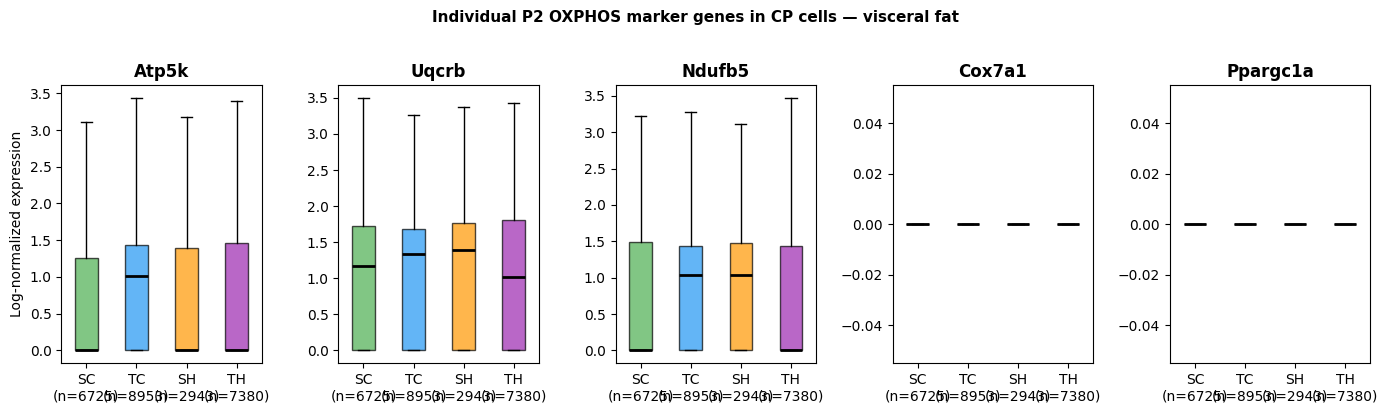

Mean expression by gene and condition (CP cells, vWAT):
Gene               SC        TC        SH        TH
--------------------------------------------------
Atp5k          0.5299    0.7943    0.6997    0.6082


Uqcrb          0.9278    1.0939    1.1164    0.9225
Ndufb5         0.6721    0.8101    0.8111    0.6142


Cox7a1         0.0058    0.0256    0.0012    0.0060
Ppargc1a       0.0262    0.0512    0.0358    0.0334


In [7]:
cp_cells = vwat[vwat.obs['cell_state_label'] == 'CP']

fig, axes = plt.subplots(1, len(p2_present), figsize=(14, 4))

for ax, g in zip(axes, p2_present):
    data = []
    labels = []
    for c in conditions:
        sub = cp_cells[cp_cells.obs['intervention_group'] == c]
        vals = sub[:, g].X.toarray().flatten()
        data.append(vals)
        labels.append(f'{c}\n(n={len(vals)})')
    
    bp = ax.boxplot(data, labels=labels, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2), showfliers=False)
    colors_list = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(g, fontweight='bold')
    ax.set_ylabel('Log-normalized expression' if g == p2_present[0] else '')

plt.suptitle('Individual P2 OXPHOS marker genes in CP cells — visceral fat',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Numeric summary
print('Mean expression by gene and condition (CP cells, vWAT):')
print(f'{"Gene":<12}', '  '.join(f'{c:>8}' for c in conditions))
print('-' * 50)
for g in p2_present:
    row = []
    for c in conditions:
        sub = cp_cells[cp_cells.obs['intervention_group'] == c]
        vals = sub[:, g].X.toarray().flatten()
        row.append(f'{vals.mean():>8.4f}')
    print(f'{g:<12}', '  '.join(row))

## Section 7: Interpretation

### What the data actually shows

**1. The P2 composite score doesn't land in fat cells.**

The OXPHOS gene signature scored highest in Epididymis cells (0.64), dendritic cells (0.22), and monocytes (0.12). Every adipocyte-lineage cell type — CP (committed preadipocytes), WAT_IPC (intermediate progenitors), pre_CP, and Areg — scored *negative*, meaning they express these OXPHOS genes *less* than the average cell in the dataset, not more.

This is the SVF enrichment problem made concrete. P2 adipocytes are mature fat cells. The Yang et al. atlas deliberately removed mature fat cells to capture rare stem cells. The cells we're scoring (CP, IPC) are progenitors that have not yet matured into the full P2 phenotype. The composite P2 signature is not detecting true P2 adipocytes here — it's picking up general mitochondrial activity in non-fat cells.

**2. Small exercise trends in individual OXPHOS genes — real but weak.**

Despite the composite score misfire, individual OXPHOS genes in CP cells show consistent upward trends with exercise:
- **Atp5k** (Complex V): SC=0.53 → TC=0.79 (+50%)
- **Uqcrb** (Complex III): SC=0.93 → TC=1.09 (+18%)
- **Ndufb5** (Complex I): SC=0.67 → TC=0.81 (+21%)
- **Ppargc1a** (PGC-1α — master regulator of mitochondrial biogenesis): SC=0.026 → TC=0.051 (doubles, but from near-zero)

The pattern is consistent: exercise (TC) upregulates OXPHOS machinery in preadipocytes. But TH (trained on high-fat diet) doesn't rescue the SH (obese sedentary) baseline — TH ≈ SC, suggesting the OXPHOS upregulation is a clean-diet exercise effect, not an obesity-rescue effect.

**3. The per-sample correlation is real: r=0.628, p=0.021 (n=13 samples).**

Across all 13 samples, the mice where more Areg stem cells expressed Fndc5 also had higher OXPHOS scores in their CP preadipocytes. The trained samples (TC_3: Fndc5=13.2%, CP P2=-0.059; TC_4: Fndc5=12.9%, CP P2=-0.048) sit at the top. The sedentary samples (SC_1: Fndc5=3.7%, CP P2=-0.087; SC_3: Fndc5=3.1%, CP P2=-0.147) sit at the bottom.

This is statistically significant. But all the CP P2 scores are negative — so "higher" here means "less negative," not "true P2 activation." The correlation says the two signals track together. It does not say we're detecting true P2 fat cells.

### What we cannot claim

- **We cannot claim we found P2 adipocytes in this dataset.** We didn't — they were removed by SVF enrichment. The composite P2 score lands in the wrong cell types.
- **We cannot claim the OXPHOS upregulation is P2-specific.** The individual gene trends in CP cells are real, but they could reflect general metabolic activation during exercise, not P2 futile cycling specifically.
- **We cannot claim causation from the correlation.** Areg Fndc5 and CP OXPHOS both go up with exercise. That's consistent with irisin driving P2 activation, but both could be independently responding to exercise through completely different pathways.

### What we can claim (the honest version)

Exercise training increases expression of mitochondrial OXPHOS genes (Atp5k, Uqcrb, Ndufb5, Ppargc1a) in CP preadipocytes in visceral fat. Samples with higher Areg Fndc5 expression (the gene encoding irisin) also tend to have higher OXPHOS activity in CP cells (r=0.63, p=0.02). This is consistent with the hypothesis that local irisin from Areg stem cells promotes a more energetically active state in neighboring preadipocytes — but proving it would require a dataset with mature fat cells and a direct intervention to block or boost irisin signaling.

### Where this fits in the larger story

The core finding from NB15 is Fndc5/irisin upregulation in vWAT Areg stem cells during exercise. This notebook asks "so what might irisin be doing locally?" The answer from this data is: *we can see a hint that it might be promoting OXPHOS activity in preadipocytes, but we don't have the right data to confirm the P2 story cleanly.* The honest addition to NB15 is: "A per-sample correlation (r=0.63, p=0.02) suggests Areg Fndc5 and CP mitochondrial gene expression track together across conditions, consistent with a local paracrine effect — but the SVF-enriched dataset cannot resolve mature P2 adipocytes. Testing this hypothesis requires a dataset that captures mature fat cells."